Install libraries

In [1]:
import pandas as pd
import pyreadstat
import re
import numpy as np
from gcsfs import GCSFileSystem
import tempfile 
#from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt


#set year of UCR data
year=2024

Define access to Google Cloud Storage Buckets

In [5]:
#run in Google Cloud SDK shell: 
# gcloud auth application-default login
fs = GCSFileSystem(project='clgx-gis-app-dev-06e3', token='google_default')

#Path to GCS buckets
gcs_path = "gs://geospatial-projects/location_inc"

In [6]:
def read_sav_from_gcs(gcs_path: str, fs: GCSFileSystem) -> pd.DataFrame:
    with fs.open(gcs_path, "rb") as gcs_file:
        # Write the content to a temporary file
        with tempfile.NamedTemporaryFile(delete=False) as temp_file:
            temp_file.write(gcs_file.read())
            temp_file.flush()
            temp_file.close()

            # Read the .sav file using pyreadstat
            df, meta = pyreadstat.read_sav(temp_file.name)
    
    return df, meta

In [7]:
def write_sav_to_gcs(df: pd.DataFrame, gcs_path: str, fs: GCSFileSystem) -> None:
    try:
        # Create local empty temporary file
        with tempfile.NamedTemporaryFile(delete=False) as temp_file:
            temp_file.close()
            
            # Add data into local sav file
            pyreadstat.write_sav(df, temp_file.name)
            
            # Load local sav file to GCS
            with open(temp_file.name, "rb") as temp_file_read:
                with fs.open(gcs_path, "wb") as gcs_file:
                    gcs_file.write(temp_file_read.read())
    except Exception as e:
        print(f"Failed to write .sav file to GCS: {e}")

Load data from previous steps in crime update pipeline

In [8]:
#crime_path = fr'{path}\Crime Dev\UCR {year}'
crime_path = f"{gcs_path}/crime/{year}"

In [9]:
#open dataframe with census tract and agency level data created in previous step
ct_muni_df, meta = read_sav_from_gcs(f"{crime_path}/ct_muni_df.sav", fs)

In [10]:
#get block group level dataframe
bg_df, meta = read_sav_from_gcs(f"{crime_path}/bg_data.sav", fs)

Define predictor features used in previous model versions


In [11]:
#predictors for variates other than 7:
us_predictors = 'zmarried_pct   zlg10_jobs_5min  zdet_pct  zlg10_grandkids_pct  zlg10_job_density \
zcol_pct zin_household_pct zlg10_dorms_pct znonfam_pct zsqrt_moved1yr_pct \
zcity_centers_dist zcommtime15_pct zgini_index zlg10_lower_homevalue zlg10_pop_ch_1mile \
zlg10_pop_ch_50mile zlg10_pop_est_5mile zlg10_seasonal_pct zmd_yrbuilt zmrpct_val_rm \
zsqrt_avg_hhsize zsqrt_jobs_45min zsqrt_md_retax zsqrt_pop_est_50mile zsqrt_singleparent_pct \
zsqrt_unemp_pct zsqrt_vacant_pct  encentral midatlantic southatlantic zusrpct_total_sc'.split()
#predictors for PR based on availability
pr_predictors = 'zmarried_pct zdet_pct zlg10_grandkids_pct zcol_pct zin_household_pct zlg10_dorms_pct znonfam_pct \
zcommtime15_pct zgini_index zlg10_lower_homevalue zlg10_seasonal_pct zmd_yrbuilt zmrpct_val_rm zsqrt_avg_hhsize \
zsqrt_singleparent_pct zsqrt_unemp_pct zsqrt_vacant_pct'.split()
#predictors for VI based on availability
vi_predictors = 'zin_household_pct zlg10_dorms_pct znonfam_pct zlg10_seasonal_pct zsqrt_avg_hhsize \
        zsqrt_singleparent_pct zsqrt_vacant_pct'.split()
print(round(100*ct_muni_df[
    (ct_muni_df[['pr','vi']].sum(axis=1)==0)&(ct_muni_df[us_predictors].notna().all(axis=1))]['popest'].sum()/ct_muni_df[
    (ct_muni_df[['pr','vi']].sum(axis=1)==0)]['popest'].sum(),2),'% of locations with valid data in 50 US States + DC')
print(round(100*ct_muni_df[(ct_muni_df['pr']==1)&(ct_muni_df[pr_predictors].notna().all(axis=1))]['popest'].sum()/ct_muni_df[
    (ct_muni_df['pr']==1)]['popest'].sum(),2),'% of locations with valid data in Puerto Rico')
print(round(100*ct_muni_df[(ct_muni_df['vi']==1)&(ct_muni_df[vi_predictors].notna().all(axis=1))]['popest'].sum()/ct_muni_df[
    (ct_muni_df['vi']==1)]['popest'].sum(),2),'% of locations with valid data in Virgin Islands')

99.51 % of locations with valid data in 50 US States + DC
100.0 % of locations with valid data in Puerto Rico
100.0 % of locations with valid data in Virgin Islands


In [12]:
#zero fill missing variabls where not available in PR
ct_muni_df.loc[(ct_muni_df['pr']==1)&(ct_muni_df[pr_predictors].notna().all(axis=1)),us_predictors
               ]=ct_muni_df[(ct_muni_df['pr']==1)&(ct_muni_df[pr_predictors].notna().all(axis=1))
                   ][us_predictors].fillna(value=0)

#zero fill missing variabls where not available in VI
ct_muni_df.loc[(ct_muni_df['vi']==1)&(ct_muni_df[vi_predictors].notna().all(axis=1)),us_predictors
               ]=ct_muni_df[(ct_muni_df['vi']==1)&(ct_muni_df[vi_predictors].notna().all(axis=1))
                   ][us_predictors].fillna(value=0)

In [13]:
#remove predictors flagged in governance review
#new_predictors = list(set(us_predictors)-{'zlg10_grandkids_pct','zmarried_pct','znonfam_pct','zsqrt_singleparent_pct'})

#only predictors reviewed by governance 
app_predictors = ['zlg10_pop_est_5mile', 'zlg10_jobs_5min',  'zin_household_pct',
                   'zcol_pct', 'zsqrt_moved1yr_pct', 'zsqrt_vacant_pct', 'zlg10_job_density', 'zgini_index', 'zcity_centers_dist',
                     'zmrpct_val_rm', 'encentral',  'zusrpct_total_sc', 'zsqrt_md_retax', 
                       'zdet_pct',  'southatlantic',  'zlg10_dorms_pct', 'midatlantic','zsqrt_unemp_pct', ]

#replace four removed with four additional predictors
new_predictors = app_predictors + ['zlg10_pop_ch_1mile','zsqrt_jobs_45min','zsqrt_pop_est_50mile','zlg10_seasonal_pct']


Define crime types making up total crime rate

In [14]:
#indicator of census tract level data
ct_muni_df['ct_data'] = ct_muni_df['ct_key'].str.len().replace({11:1,7:0,5:0})

crimes = ['violent','murder','rape','robbery','assault','property','burglary','larceny','mvt']
primary_crimes = list(set(crimes)-set(['violent','property']))
for i in crimes:
    #update retro and projected city level crime rates
    if ct_muni_df.groupby('akey')[f'{i}_pt_m'].std().max()==0:
        ct_muni_df[f'{i}_pt_m'] = ct_muni_df[f'{i}_pt_m']*(1 + ((ct_muni_df['year'] - year)*ct_muni_df[f'pctch_{i}_pt']))
    ct_muni_df[f'{i}_pt_m'] = ct_muni_df[f'{i}_pt_m'].mask(ct_muni_df[f'{i}_pt_m']<0,0)   
    #populate city crime for all census tracts in city
    ct_muni_df.set_index(['akey','year'],inplace=True)
    ct_muni_df[f'{i}_pt_m'] = ct_muni_df.groupby(['akey','year'])[f'{i}_pt_m'].max()
    ct_muni_df.reset_index(inplace=True)
    #log dependent variable
    ct_muni_df[f'log_{i}'] = np.log10(1 + ct_muni_df[f'ucr_{i}_pt_m'])

Create agency total crime rate weighted by crime severity

In [15]:
#sum up city crime weighted by severity
ct_muni_df.loc[ct_muni_df[['violent_pt_m','property_pt_m']].notna().any(axis=1),'total_rel_m']=0
#join us crime totals
us_df, meta = read_sav_from_gcs(f"{crime_path}/ucr_us.sav", fs)
#us_df = pd.read_spss(fr'{crime_path}\ucr_us.sav')
for i in crimes:
    ct_muni_df[f'{i}_pt_u'] = us_df[f'ucr_{i}_rate_u'][0]
#each primary crime type contributes 1/7 to total
for i in primary_crimes:
    ct_muni_df['total_rel_m'] = ct_muni_df['total_rel_m'] + ct_muni_df[f'{i}_pt_m']/ct_muni_df[f'{i}_pt_u']/7
ct_muni_df['wtotal_pt_m'] = ct_muni_df['total_rel_m'] * ct_muni_df[['violent_pt_u','property_pt_u']].sum(axis=1)    


Define agency level data set for testing and training

In [16]:
#test and train on agencies with complete data and at least 1,000 population
us_muni = ct_muni_df[
    (ct_muni_df['primary_place']==1)&(ct_muni_df['wtotal_pt_m'].notna())&(
    ct_muni_df['population_m']>=1000)&(ct_muni_df[us_predictors].notna().all(axis=1))
    ].set_index('akey')

In [17]:
#define predictor features, and include weighting factor
X = us_muni[us_predictors + ['population_m']]
#define targets for all crime models
y = us_muni[['population_m','wtotal_pt_m']+[i+"_pt_m" for i in crimes]]


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,random_state=99999)#CHANGE RANDOM STATE TO ANY NUMBER


print("CONFIRM TRAIN AND TEST HAVE SIMILAR AVERAGE")
print("if not change random state parameter and rerun")
print()
print("Train weighted average total rate:",
round(np.average(y_train['wtotal_pt_m'],weights=y_train['population_m']),2),","
,y_train['wtotal_pt_m'].count(),"agencies")
print("Test weighted average total rate:",
round(np.average(y_test['wtotal_pt_m'],weights=y_test['population_m']),2),","
,y_test['wtotal_pt_m'].count(),"agencies")

CONFIRM TRAIN AND TEST HAVE SIMILAR AVERAGE
if not change random state parameter and rerun

Train weighted average total rate: 21.09 , 9580 agencies
Test weighted average total rate: 19.99 , 3194 agencies


Define functions for model development

In [19]:
#histogram plotting function
def plot_histo(y, label, weights, ax):
    ax.hist(y, bins=max(50,round(y.max()/2)),
             density=True, weights=weights)
    ax.set_xlim([y.min(), min(100,y.max())])
    ax.set_ylabel("Probability")
    ax.set_title(label)

In [20]:
def histo(crime, label, pop_cut):
    #temp names for specific crime train and test
    y_train_ = y_train[y_train['population_m']>pop_cut][f'{crime}_pt_m']
    X_train_ = X_train[X_train['population_m']>pop_cut]

    # Create histogram
    fig, axes = plt.subplots(1, 2)#, figsize=(10, 6)) # Adjust layout as needed
    # Plot for Model 1
    plot_histo( y_train_,f'{label} Rate per 1,000',X_train_['population_m'], axes[0])
    # Plot for Model 2
    plot_histo( np.log1p(y_train_),f'Log {label} Rate per 1,000',X_train_['population_m'], axes[1])
    fig.suptitle(f"{label} Rate for Training Agencies \n Weighted by Population", y=1.05)
    plt.tight_layout()


In [21]:
#function for model fit
def compute_score(y_true, y_pred, weight=None):
    return {
        "R2": f"{r2_score(y_true, y_pred, sample_weight=weight):.3f}",
        "MAE": f"{mean_absolute_error(y_true, y_pred, sample_weight=weight):.3f}",
        "n": f"{y_true.count():,}"
    }

In [22]:
def plot_observed_vs_predicted(observed, predicted, model_name, ax):
    min_val = min(observed.min(), predicted.min())
    max_val = max(observed.max(), predicted.max())
    ax.scatter( observed, predicted, alpha=0.6, label=model_name)
    ax.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='1:1 Line')
    ax.set_ylabel('Predicted Crime Rate')
    ax.set_xlabel('Observed Crime Rate')
    ax.set_title(f'Model fit: 250 largest agencies,\n {model_name}')
    ax.legend()
    ax.grid(True)

In [26]:
def ridge(crime, label, pop_cut, predictors):
    #temp names for specific crime train and test
    y_train_ = y_train[y_train['population_m']>pop_cut][f'{crime}_pt_m']
    y_test_ = y_test[y_test['population_m']>pop_cut][f'{crime}_pt_m']

    X_train_ = X_train[X_train['population_m']>pop_cut]
    X_test_ = X_test[X_test['population_m']>pop_cut]
    
    model = TransformedTargetRegressor(
        #regressor=Ridge(alpha=1e-10),func=np.log1p, inverse_func=np.expm1
        regressor=RidgeCV(),func=np.log1p, inverse_func=np.expm1
    )

    model.fit(X_train_[predictors], y_train_,
               sample_weight=X_train_['population_m'])
    
    #check the fit of the new model for train and test
    train_fit = compute_score(y_train_, model.predict(X_train_[predictors]), X_train_['population_m'])
    test_fit = compute_score(y_test_, model.predict(X_test_[predictors]), X_test_['population_m'])
    print(f"Training Fit for {label} Rate:")
    print("MAE:",train_fit['MAE'],"; R-sq:",train_fit['R2'],"; n:",train_fit['n'])
    print(f"Testing Fit for {label} Rate:")
    print("MAE:",test_fit['MAE'],"; R-sq:",test_fit['R2'],"; n:",test_fit['n'])

    #define top top 100 munis in test set and join y values
    train_top = X_train_.join(y_train_).sort_values(by='population_m', ascending=False).head(250)
    test_top = X_test_.join(y_test_).sort_values(by='population_m', ascending=False).head(250)

    #sample cities from testing
    pred_3_train = model.predict(train_top[predictors])
    pred_3_test = model.predict(test_top[predictors])
    obs_train = train_top[f'{crime}_pt_m']
    obs_test = test_top[f'{crime}_pt_m']

    # Create a figure with subplots for each model
    fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Adjust layout as needed
    # Plot for Model 1
    plot_observed_vs_predicted(obs_train, pred_3_train, f'{label} Rate Training', axes[0])
    # Plot for Model 2
    plot_observed_vs_predicted(obs_test, pred_3_test, f'{label} Rate Testing', axes[1])
    plt.tight_layout()

    #save coefficients
    coeff = pd.concat([
    pd.DataFrame(model.regressor_.coef_ , model.feature_names_in_  , columns=[crime]),
    pd.DataFrame(model.regressor_.intercept_, ['(constant)'], columns=[crime])
    ])

    #try joining to existing table
    try: coeff_table_new = coeff_table.join(coeff)
    #else replace
    except: coeff_table_new = coeff

    #apply predictions to census tracts
    ct_muni_df.loc[
        ct_muni_df[predictors].notna().all(axis=1),f'{crime}_pred'
        ] = model.predict(
        ct_muni_df[ct_muni_df[predictors].notna().all(axis=1)][predictors]
        )
    #apply predictions to block groups
    bg_df.loc[
        bg_df[predictors].notna().all(axis=1),f'{crime}_pred'
        ] = model.predict(
        bg_df[bg_df[predictors].notna().all(axis=1)][predictors]
        )    

    return model, coeff_table_new

Apply existing total crime model

In [24]:
def prod_model(df):
    pre_0 = 0.735363729227869 + \
    df.encentral*-0.0750655707160974 + \
    df.midatlantic*-0.106659704600788 + \
    df.southatlantic*-0.0301289648166711 + \
    df.zcity_centers_dist*-0.0174767600736059 + \
    df.zcol_pct*-0.0531657308652685 + \
    df.zdet_pct*0.0434734199401469 + \
    df.zgini_index*0.0244913704984118 + \
    df.zin_household_pct*0.0627426427705564 + \
    df.zlg10_dorms_pct*0.0213130242833591 + \
    df.zlg10_grandkids_pct*0.0389564042363203 + \
    df.zlg10_job_density*0.0294635169957484 + \
    df.zlg10_jobs_5min*0.0372182860718184 + \
    df.zlg10_pop_est_5mile*0.054308822184627 + \
    df.zmarried_pct*-0.0792964753161211 + \
    df.zmrpct_val_rm*-0.0241918772302992 + \
    df.znonfam_pct*0.0707434595102681 + \
    df.zsqrt_md_retax*-0.0249449998933163 + \
    df.zsqrt_moved1yr_pct*0.0428032528483494 + \
    df.zsqrt_singleparent_pct*0.093512818053506 + \
    df.zsqrt_unemp_pct*0.0308704901910884 + \
    df.zsqrt_vacant_pct*0.0434164783546601 + \
    df.zusrpct_total_sc*-0.0338628170324897
    wtotal_pred = 10**pre_0
    return wtotal_pred

#apply model to test munis
unscaled_pred = prod_model(X_test)

#adjust predictions to match true average   
scaling_factor = np.average(y_test['wtotal_pt_m'],weights=X_test['population_m']) / np.average(
        unscaled_pred,weights=X_test['population_m'])

#check the fit of existing model for train and test
y_train_pred_0 = prod_model(X_train) * scaling_factor
y_test_pred_0 = prod_model(X_test) * scaling_factor

train_fit_0 = compute_score(y_train['wtotal_pt_m'],y_train_pred_0,X_train['population_m'])
test_fit_0 = compute_score(y_test['wtotal_pt_m'],y_test_pred_0,X_test['population_m'])

print("Training Fit for Existing Weighted Total Crime Model:")
print("MAE:",train_fit_0['MAE'],"; R-sq:",train_fit_0['R2'],"; n:",train_fit_0['n'])
print("Testing Fit for Existing Weighted Total Crime Model:")
print("MAE:",test_fit_0['MAE'],"; R-sq:",test_fit_0['R2'],"; n:",test_fit_0['n'])

Training Fit for Existing Weighted Total Crime Model:
MAE: 7.285 ; R-sq: 0.613 ; n: 9,580
Testing Fit for Existing Weighted Total Crime Model:
MAE: 7.075 ; R-sq: 0.630 ; n: 3,194


In [28]:
#apply predictions to census tracts
ct_muni_df['wtotal_pred'] = prod_model(ct_muni_df)* scaling_factor
bg_df['wtotal_pred'] = prod_model(bg_df)* scaling_factor


Total Weighted Crime Rate Model

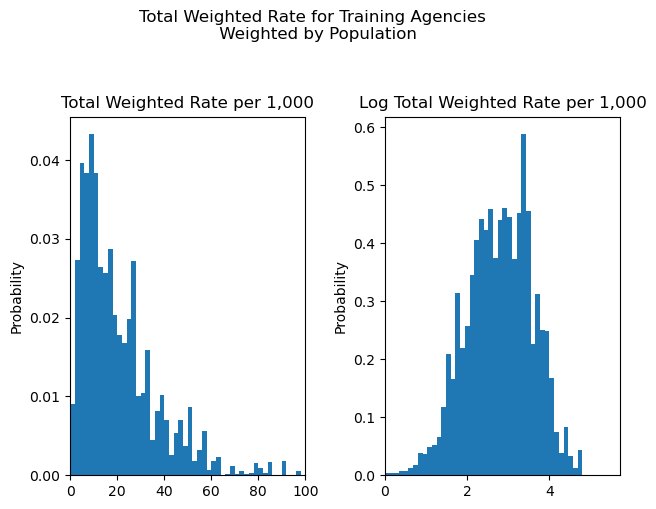

In [25]:
histo('wtotal', "Total Weighted", 1000)

Total model retrain

In [ ]:
#don't retrain total model until approved

#model_total, coeff_table = ridge('wtotal', "Total Weighted", 1000, new_predictors)

Violent


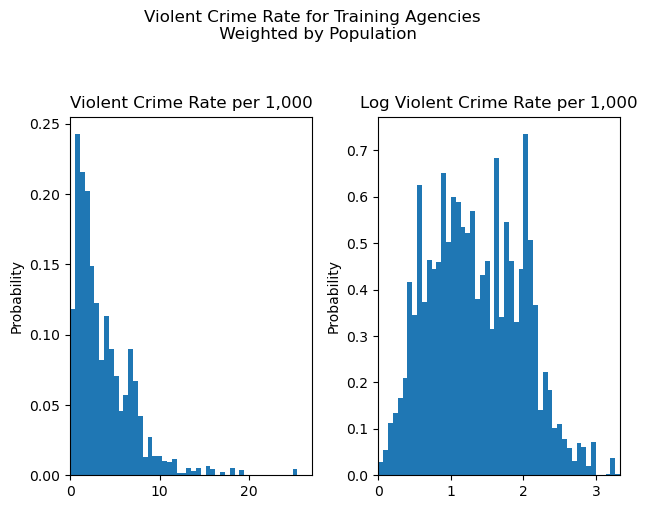

In [30]:
#RERUN TO GET THE MOST NORMAL LOG DISTRO POSSIBILE
histo('violent',"Violent Crime",10000) #ADJUST MIN POPULATION HERE


Training Fit for Violent Crime Rate:
MAE: 1.294 ; R-sq: 0.609 ; n: 4,389
Testing Fit for Violent Crime Rate:
MAE: 1.131 ; R-sq: 0.672 ; n: 1,481


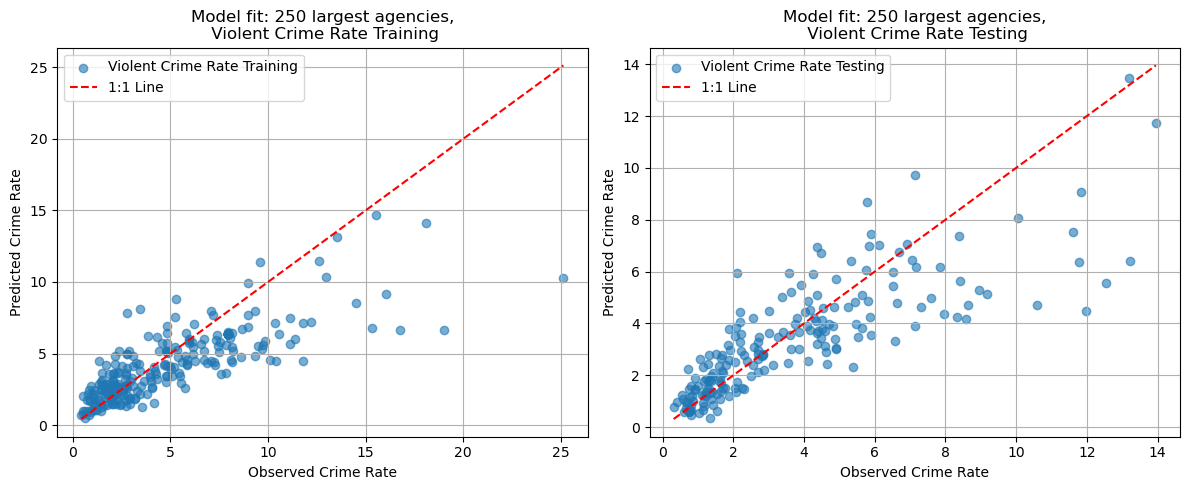

In [31]:
#USE SAME PARAMETERS AS ABOVE
model_violent, coeff_table = ridge('violent',"Violent Crime",10000,new_predictors)

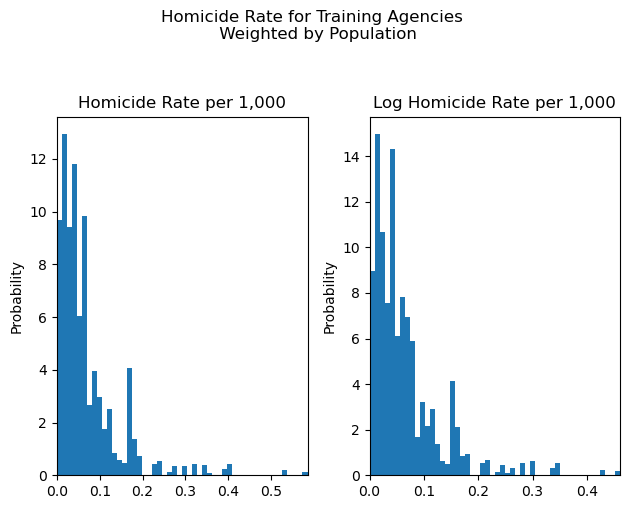

In [32]:
#RERUN TO GET THE MOST NORMAL LOG DISTRO POSSIBILE
histo('murder',"Homicide",100000) #ADJUST MIN POPULATION HERE

Training Fit for Homicide Rate:
MAE: 0.029 ; R-sq: 0.649 ; n: 436
Testing Fit for Homicide Rate:
MAE: 0.032 ; R-sq: 0.527 ; n: 119


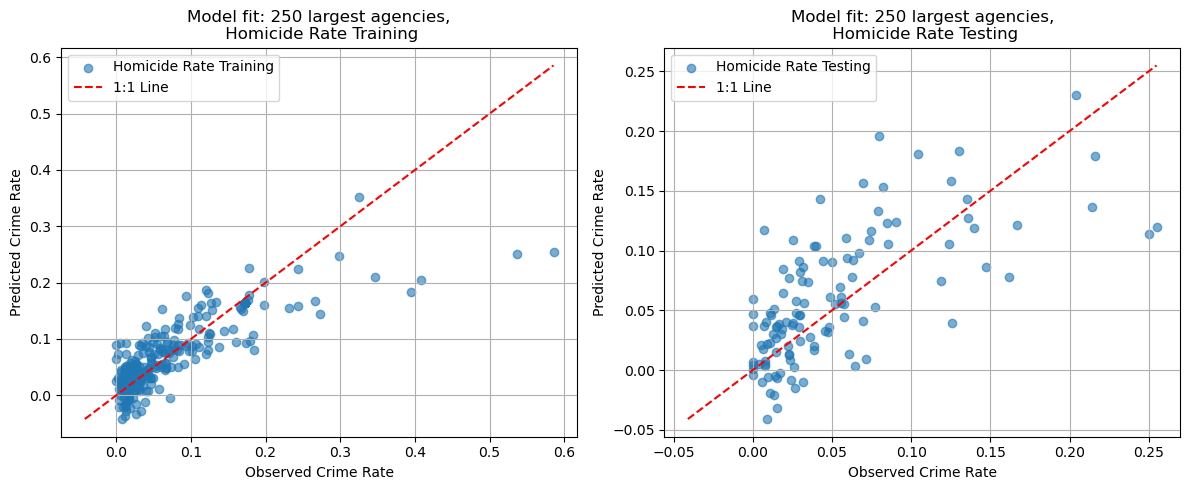

In [33]:
#USE SAME PARAMETERS AS ABOVE
model_murder, coeff_table = ridge('murder',"Homicide",100000,new_predictors)

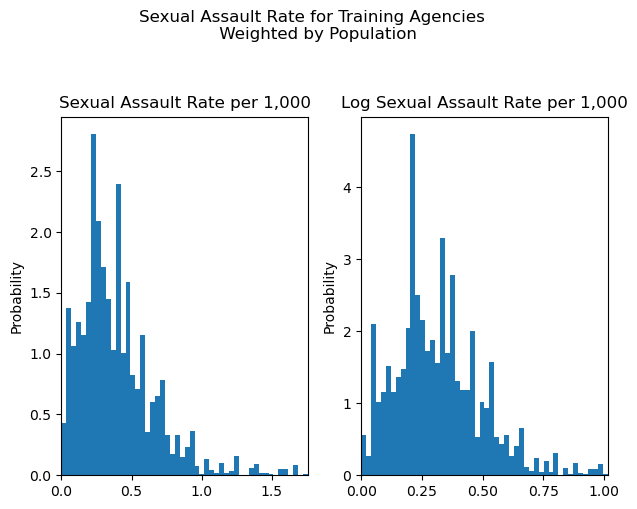

In [34]:
histo('rape','Sexual Assault',50000)

Training Fit for Sexual Assault Rate:
MAE: 0.138 ; R-sq: 0.447 ; n: 1,086
Testing Fit for Sexual Assault Rate:
MAE: 0.167 ; R-sq: 0.314 ; n: 339


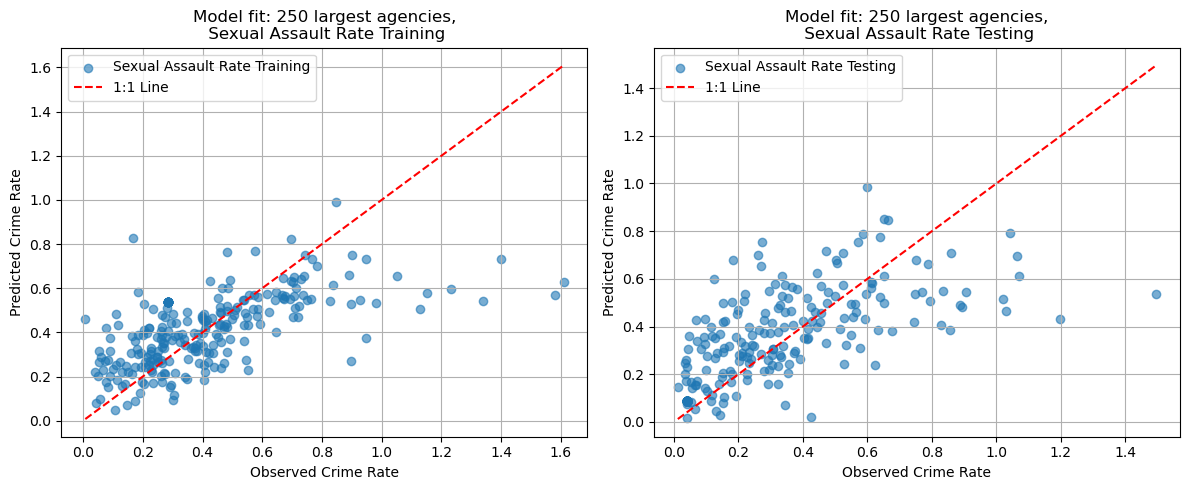

In [35]:
model_rape, coeff_table = ridge('rape','Sexual Assault',50000,new_predictors)

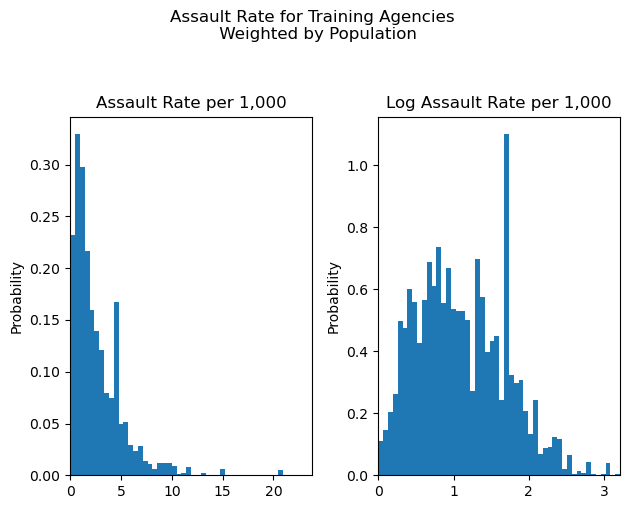

In [36]:
histo('assault',"Assault",10000)

Training Fit for Assault Rate:
MAE: 1.053 ; R-sq: 0.533 ; n: 4,389
Testing Fit for Assault Rate:
MAE: 0.884 ; R-sq: 0.604 ; n: 1,481


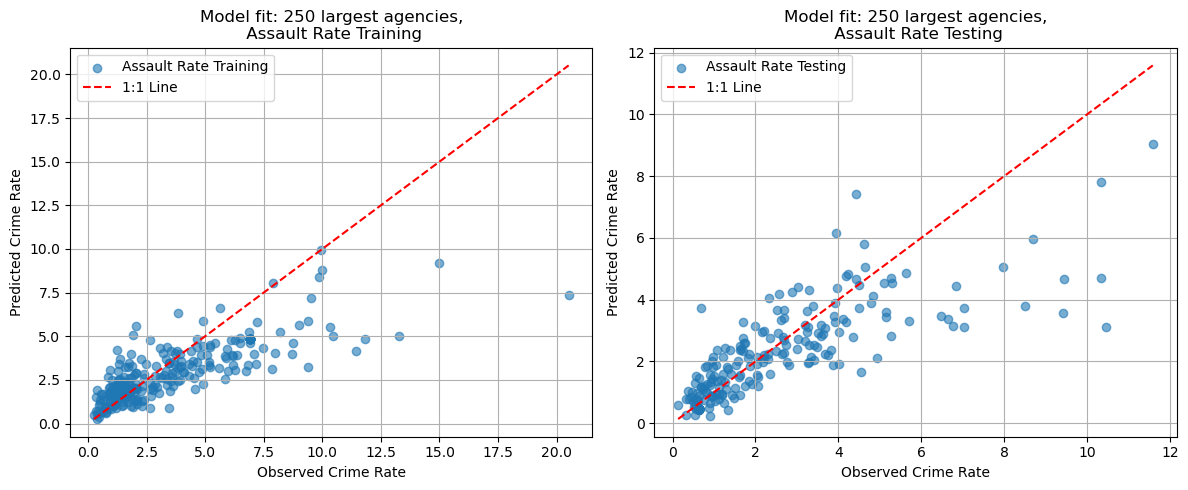

In [37]:
model_assault, coeff_table = ridge('assault',"Assault",10000,new_predictors)

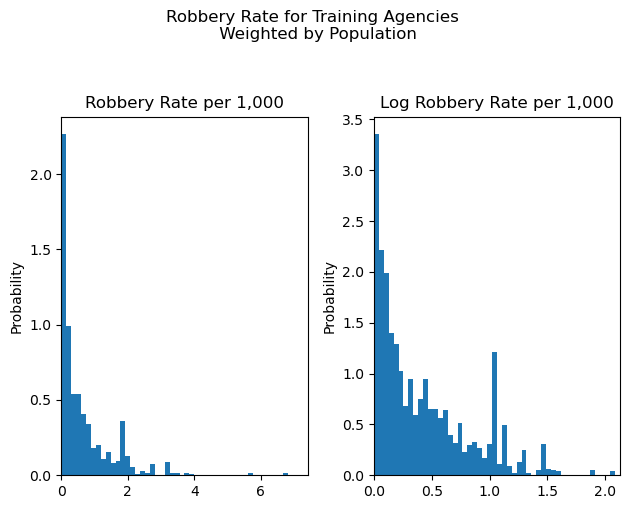

In [38]:
histo('robbery',"Robbery",10000)

Training Fit for Robbery Rate:
MAE: 0.289 ; R-sq: 0.637 ; n: 4,389
Testing Fit for Robbery Rate:
MAE: 0.275 ; R-sq: 0.640 ; n: 1,481


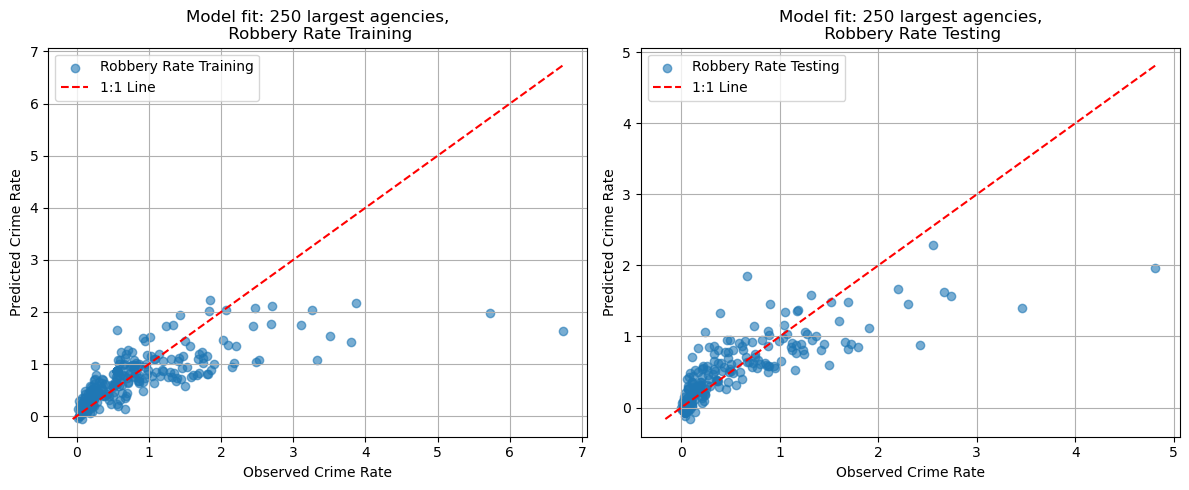

In [39]:
model_robbery, coeff_table = ridge('robbery',"Robbery",10000,new_predictors)

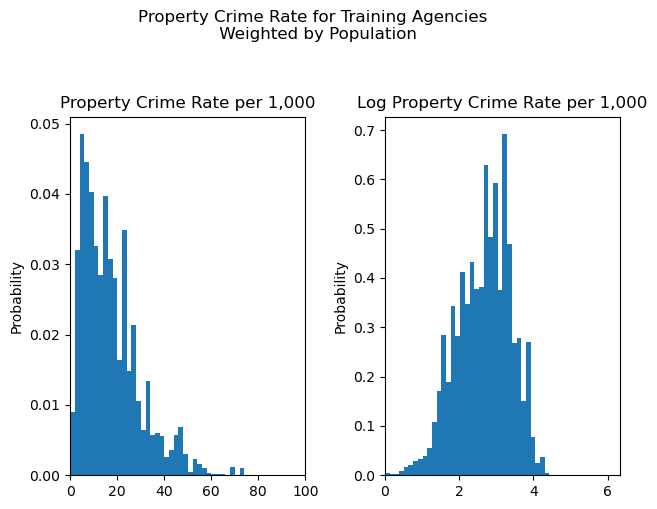

In [40]:
histo('property',"Property Crime",1000)

Training Fit for Property Crime Rate:
MAE: 5.518 ; R-sq: 0.548 ; n: 9,580
Testing Fit for Property Crime Rate:
MAE: 5.217 ; R-sq: 0.590 ; n: 3,193


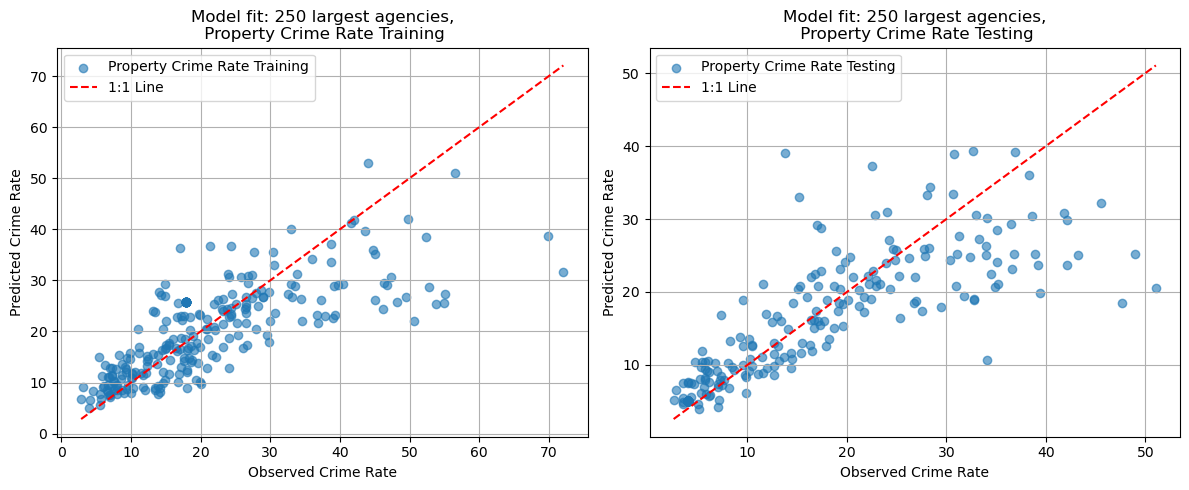

In [41]:
model_property, coeff_table = ridge('property',"Property Crime",1000,new_predictors)

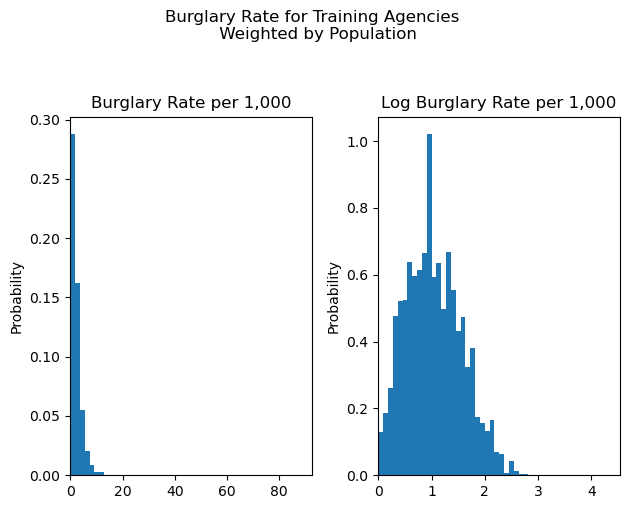

In [42]:
histo('burglary',"Burglary",1000)

Training Fit for Burglary Rate:
MAE: 0.935 ; R-sq: 0.420 ; n: 9,580
Testing Fit for Burglary Rate:
MAE: 0.933 ; R-sq: 0.419 ; n: 3,193


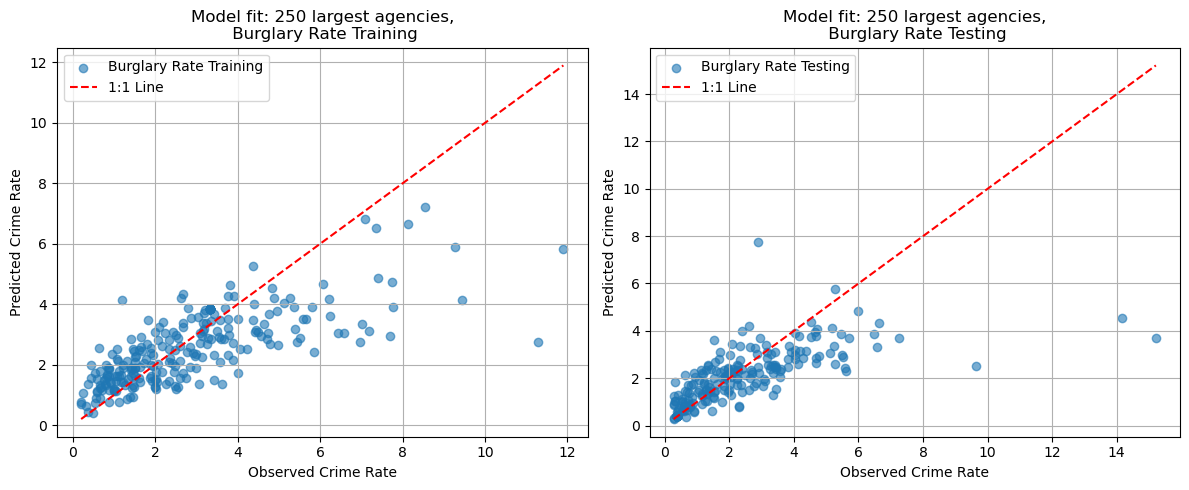

In [43]:
model_burglary, coeff_table = ridge('burglary',"Burglary",1000,new_predictors)

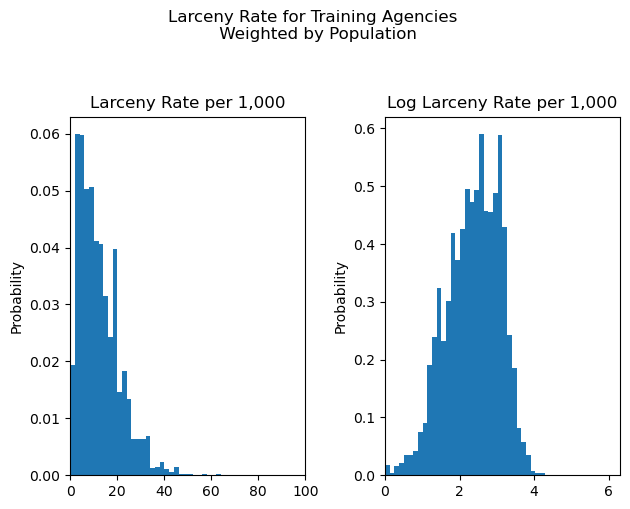

In [44]:
histo('larceny',"Larceny",1000)

Training Fit for Larceny Rate:
MAE: 4.024 ; R-sq: 0.498 ; n: 9,580
Testing Fit for Larceny Rate:
MAE: 3.913 ; R-sq: 0.521 ; n: 3,193


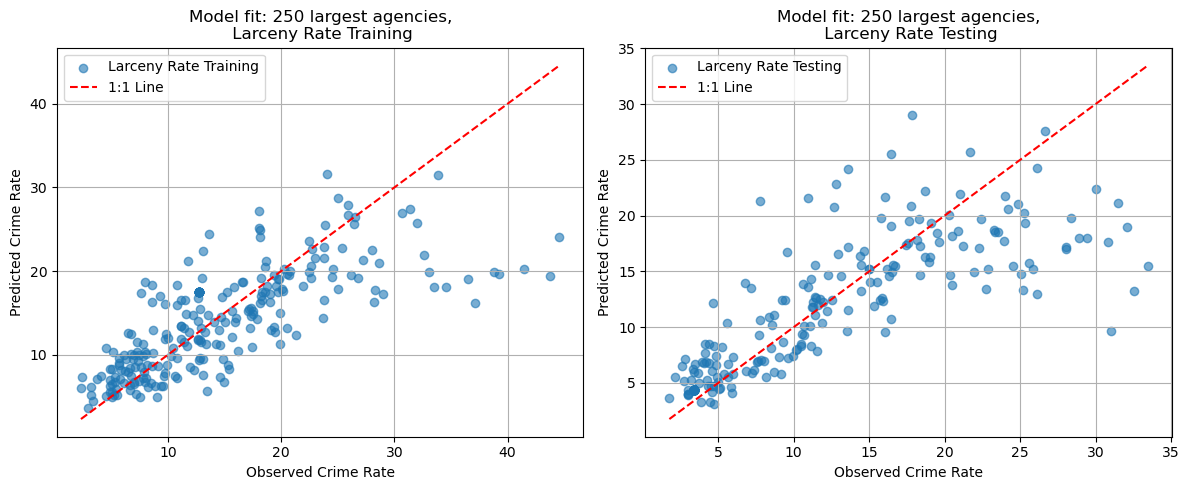

In [45]:
model_larceny, coeff_table = ridge('larceny',"Larceny",1000,new_predictors)

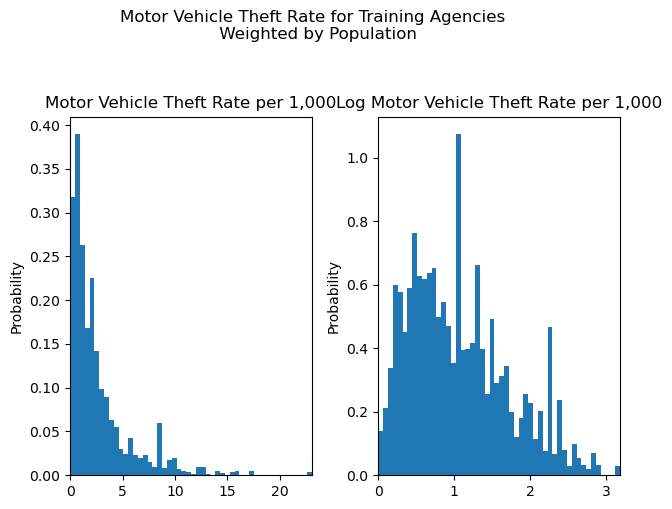

In [46]:
histo('mvt',"Motor Vehicle Theft",10000)

Training Fit for Motor Vehicle Theft Rate:
MAE: 1.266 ; R-sq: 0.493 ; n: 4,389
Testing Fit for Motor Vehicle Theft Rate:
MAE: 1.143 ; R-sq: 0.551 ; n: 1,481


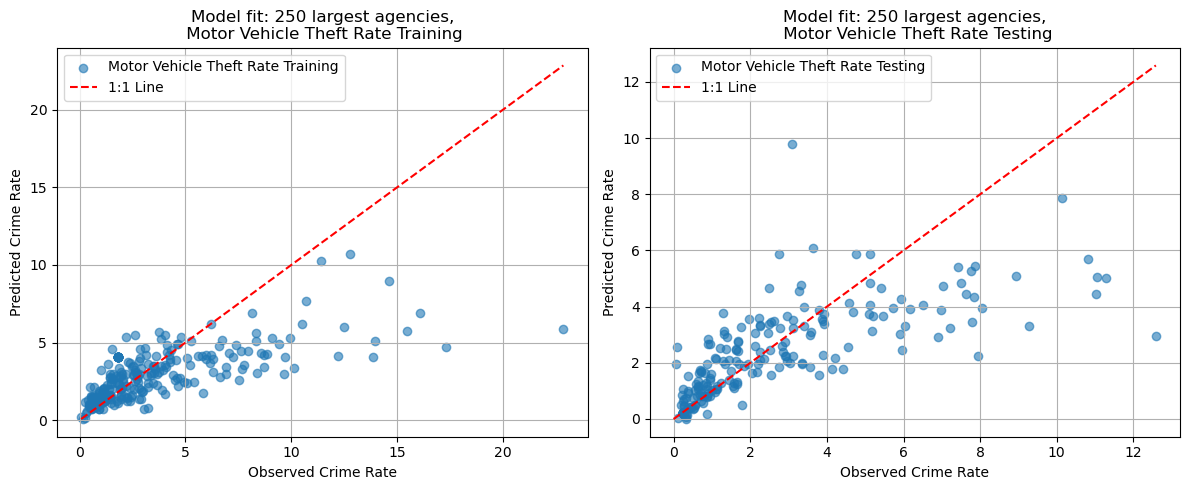

In [47]:
model_mvt, coeff_table = ridge('mvt',"Motor Vehicle Theft",10000,new_predictors)

In [48]:
#print coeff table
coeff_table

,violent,murder,rape,assault,robbery,property,burglary,larceny,mvt
zlg10_pop_est_5mile,0.206494,0.024928,-0.001545,0.173751,0.167952,0.255695,0.107562,0.228577,0.372908
zlg10_jobs_5min,0.248629,0.008955,0.082538,0.210384,0.131193,0.171234,0.176226,0.156140,0.063416
zin_household_pct,-0.011338,0.014299,-0.027199,-0.015158,0.001247,0.022801,0.008800,0.025663,0.053116
zcol_pct,-0.058900,-0.025720,0.019607,-0.077247,-0.046628,-0.039295,-0.061749,-0.027232,-0.083389
zsqrt_moved1yr_pct,0.028196,0.001379,0.069313,0.019235,-0.018127,0.104242,0.072909,0.115117,0.069923
zsqrt_vacant_pct,0.178188,0.069155,0.031397,0.160870,0.093671,0.177863,0.219542,0.132239,0.191157
zlg10_job_density,-0.077111,-0.012179,-0.016123,-0.074543,-0.028100,0.148218,-0.062171,0.231190,-0.066016
zgini_index,0.091998,0.010937,0.006767,0.102423,0.052790,0.044311,0.073669,0.034240,0.029122
zcity_centers_dist,0.032664,-0.001869,0.018656,0.010318,0.043307,-0.003407,-0.018517,0.000152,0.019654
zmrpct_val_rm,-0.077255,-0.013162,-0.043203,-0.072785,-0.027979,-0.053633,-0.043735,-0.031624,-0.114506


Check predictions for Census Tracts and Block Groups

In [49]:
print('Census Tract Level Crime Rate Predictions')
print('----------range---------')
for i in primary_crimes+['wtotal']:
    min_pred = (ct_muni_df[f'{i}_pred']-ct_muni_df[f'{i}_pred'].min())/(0.5-ct_muni_df[f'{i}_pred'].min())
    ct_muni_df[f'{i}_pred'] = ct_muni_df[f'{i}_pred'].mask(ct_muni_df[f'{i}_pred']<0.5,min_pred)
    print(i,ct_muni_df[f'{i}_pred'].min(),'-',ct_muni_df[f'{i}_pred'].max())
print('--------------------------')   

Census Tract Level Crime Rate Predictions
----------range---------
burglary 0.0 - 150.82777729189957
robbery 0.0 - 5.953320040713345
mvt 0.0 - 107.14812600864401
rape 0.0 - 5.073800881053561
assault 0.0 - 121.10968385560848
larceny 0.0 - 258.3345807050879
murder 0.0 - 2.821330824371016
wtotal 0.0 - 2628.867636041854
--------------------------


In [50]:
print('Block Group Level Crime Rate Predictions')
print('----------range---------')
for i in ['violent','property','wtotal']:
    min_pred = (bg_df[f'{i}_pred']-bg_df[f'{i}_pred'].min())/(0.5-bg_df[f'{i}_pred'].min())
    bg_df[f'{i}_pred'] = bg_df[f'{i}_pred'].mask(bg_df[f'{i}_pred']<0.5,min_pred)
    print(i,bg_df[f'{i}_pred'].min(),'-',bg_df[f'{i}_pred'].max())
print('--------------------------')  

Block Group Level Crime Rate Predictions
----------range---------
violent 0.0 - 52113.54529574061
property 0.0 - 52113.54529574061
wtotal 0.0 - 211.92804742233884
--------------------------


Replace model predictions in low sample areas

In [51]:
def wavg(df,group,weight,values):
    #new dataframe so values can be overwritten
    agg=df.copy()
    #empty dataframe indexed by the group column
    add=pd.DataFrame(columns = group).set_index(group)
    #multiply values by weight
    for i in values:
        agg[i] = agg[i] * agg[weight]
        #sum weights and values except if all NaN     
        add=add.join(agg[agg[i].notna()].groupby(group)[[i,weight]].sum(),how='outer')
        #divide values by sum of weights
        add[i] = add[i] / add[weight]
        add.drop(weight,axis=1,inplace=True)
    #return the average values    
    return add

"""wavg(df,group,weight,values) group and values to average must be entered as a list"""

'wavg(df,group,weight,values) group and values to average must be entered as a list'

In [52]:

def balance_city(crime_df,crime):
    #use muni value for missing pred, zero population and incarcerated
    use_avg = (crime_df['ct_data']==1)&((crime_df[f'{crime}_pred'].isna())|(crime_df['population_acs']<50)|(crime_df['incarc_pct']>50))
    crime_df.loc[use_avg,f'{crime}_pt']=crime_df[f'{crime}_pt_m']
    #true up predictions to city average for remaining census tracts
    true_up = (crime_df[f'{crime}_pt'].isna())&(crime_df['ct_data']==1)
    pred_avg = wavg(df=crime_df[true_up],group=['akey','year'],weight='popest',values=[f'{crime}_pred'])
    crime_df = crime_df.join(pred_avg,on=['akey','year'],rsuffix='_mean')
    crime_df.loc[true_up,f'{crime}_pt'] = crime_df[f'{crime}_pt_m'] * crime_df[f'{crime}_pred'] / crime_df[f'{crime}_pred_mean'].replace({0:.01})
    crime_df.drop(f'{crime}_pred_mean',axis=1,inplace=True)
    return crime_df


In [53]:
for i in primary_crimes+['wtotal']:
    ct_muni_df = balance_city(crime_df=ct_muni_df,crime=i)
  

True up crime rates for specific crimes to weighted total for census tracts

In [54]:
#get the weighted total rate based on specific crime models
rel=0
for i in primary_crimes:
    rel = rel+ct_muni_df[f'{i}_pt']/ct_muni_df[f'{i}_pt_u']/7 
ct_muni_df['wtotal_pt_mean'] = rel * ct_muni_df[['violent_pt_u','property_pt_u']].sum(axis=1)
#base weighted total on violent and property models in PR and VI
#ct_muni_df['wtotal_pt'] = ct_muni_df['wtotal_pt'].mask(ct_muni_df['variate']==7,ct_muni_df['wtotal_pt_mean'])

#adjust each specific crime rate to average to total model result
for i in primary_crimes:
    ct_muni_df[f'{i}_pt'] = ct_muni_df[f'{i}_pt'] * ct_muni_df['wtotal_pt'] / ct_muni_df['wtotal_pt_mean'].replace({0:.01})
    


In [55]:
#sum up totals.
ct_muni_df['violent_pt'] = ct_muni_df[['murder_pt','rape_pt','assault_pt','robbery_pt']].sum(axis=1)
ct_muni_df['property_pt'] = ct_muni_df[['burglary_pt','larceny_pt','mvt_pt']].sum(axis=1)
ct_muni_df['total_pt'] = ct_muni_df[['violent_pt','property_pt']].sum(axis=1)

for i in crimes+['total','wtotal']:
    print(i,'rate populated for',100*ct_muni_df[ct_muni_df['ct_data']==1]['year'].count()/ct_muni_df[
        ct_muni_df['ct_data']==1][f'{i}_pt'].count(),'% of census tracts') 


violent rate populated for 100.0 % of census tracts
murder rate populated for 100.0 % of census tracts
rape rate populated for 100.0 % of census tracts
robbery rate populated for 100.0 % of census tracts
assault rate populated for 100.0 % of census tracts
property rate populated for 100.0 % of census tracts
burglary rate populated for 100.0 % of census tracts
larceny rate populated for 100.0 % of census tracts
mvt rate populated for 100.0 % of census tracts
total rate populated for 100.0 % of census tracts
wtotal rate populated for 100.0 % of census tracts


In [56]:
#pyreadstat.write_sav(ct_muni_df,fr'{crime_path}\all_variate.sav')
write_sav_to_gcs(ct_muni_df, f"{crime_path}/all_variate.sav", fs)

Define block group ratios relative to census tract

In [57]:
#bg_df.set_index('ct_key',inplace=True)
for i in ['wtotal','violent','property']:
    bg_df = bg_df.join(bg_df.groupby('ct_key')[f'{i}_pred'].mean(),on='ct_key',rsuffix='_ct')
    bg_df[f'bg_ratio_{i}'] = bg_df[f'{i}_pred'] / bg_df[f'{i}_pred_ct']
    #limit ratio to range 0.5 - 2
    bg_df.loc[bg_df[f'bg_ratio_{i}']>2,f'bg_ratio_{i}']=2
    bg_df.loc[bg_df[f'bg_ratio_{i}']<0.5,f'bg_ratio_{i}']=0.5
    bg_df[f'bg_ratio_{i}'] = bg_df[f'bg_ratio_{i}'].fillna(value=1)


True up crime rates for violent and property crimes to weighted total for block groups

In [58]:
#get the weighted total rate based on specific crime models
wtotal_ratio_mean = 4* bg_df['bg_ratio_violent']/7 + 3*bg_df['bg_ratio_property']/7

#base weighted total on violent and property models in PR and VI
#bg_df['bg_ratio_wtotal'] = bg_df['bg_ratio_wtotal'].mask(bg_df['variate']==7,wtotal_ratio_mean)
#adjust each specific crime rate to average to total model result
bg_df['bg_ratio_violent'] = bg_df['bg_ratio_violent'] * bg_df['bg_ratio_wtotal'] / wtotal_ratio_mean
bg_df['bg_ratio_property'] = bg_df['bg_ratio_property'] * bg_df['bg_ratio_wtotal'] / wtotal_ratio_mean


In [59]:
#pyreadstat.write_sav(bg_df,fr'{crime_path}\bg_models.sav')
write_sav_to_gcs(bg_df, f"{crime_path}/bg_models.sav", fs)